<a href="https://colab.research.google.com/github/tien10022001/txldl/blob/main/ASM1_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving data.csv to data (1).csv
========== INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        23 non-null     int64  
 1   area         22 non-null     float64
 2   rooms        22 non-null     float64
 3   location     23 non-null     object 
 4   description  23 non-null     object 
dtypes: float64(2), int64(1), object(2)
memory usage: 1.0+ KB
None

========== HEAD ==========


,price,area,rooms,location,description
0,1000000,50.0,2.0,Hanoi,Nhà đẹp trung tâm
1,2000000,70.0,3.0,HCM,Căn hộ cao cấp view đẹp
2,1500000,60.0,2.0,Danang,Nhà gần biển thoáng mát
3,1800000,65.0,3.0,Ha Noi,Nhà phố tiện nghi
4,2200000,80.0,4.0,HCM,Căn hộ luxury cao cấp



========== STATS ==========


,price,area,rooms
count,2.300000e+01,22.000000,22.000000
mean,1.702174e+06,66.545455,2.954545
std,8.180462e+05,24.310937,1.617678
min,-1.000000e+06,0.000000,-1.000000
25%,1.350000e+06,55.750000,2.000000
50%,1.750000e+06,63.500000,3.000000
75%,2.150000e+06,74.250000,3.750000
max,3.000000e+06,120.000000,6.000000



Missing:


,0
price,0
area,1
rooms,1
location,0
description,0


Duplicate: 0


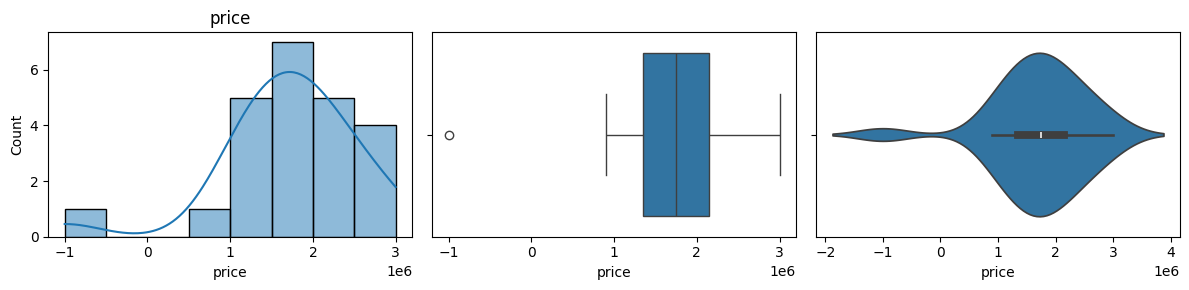

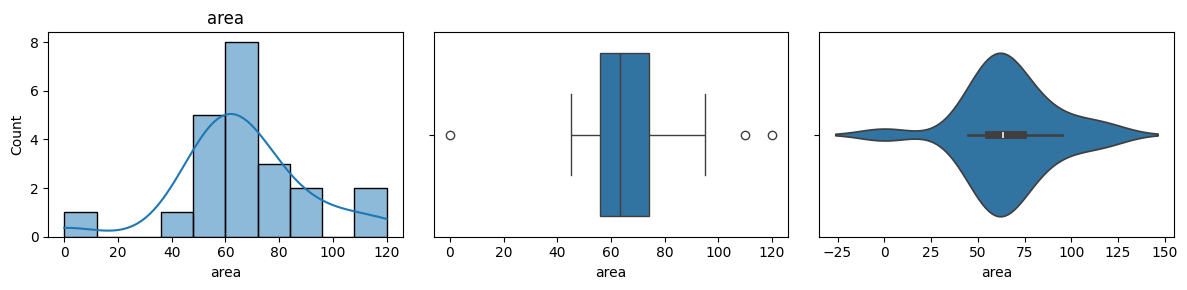

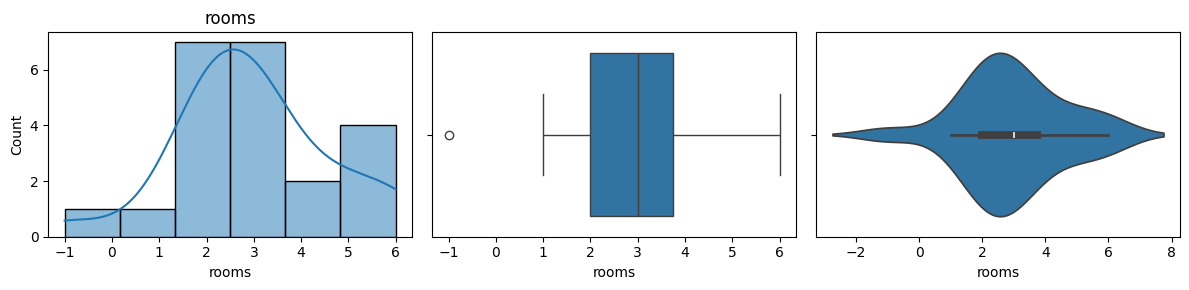

✔ CLEAN DONE
✔ OUTLIER DONE
Shape: (21, 27)
Similar pairs: 190


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Linear Regression -> RMSE: 531.77 | R2: -3236561.16
Random Forest -> RMSE: 0.10 | R2: 0.89
Pipeline RMSE: 0.0993685929554907
Pipeline R2: 0.8869863347457627
New prediction: [0.60571429 0.49761905]

🔥 DONE ALL


In [2]:
# ================================
# UPLOAD DATA
# ================================
from google.colab import files
uploaded = files.upload()  # upload data.csv

# ================================
# IMPORT
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("data.csv")

print("========== INFO ==========")
print(df.info())

print("\n========== HEAD ==========")
display(df.head())

# ================================
# STATS
# ================================
print("\n========== STATS ==========")
display(df.describe())

print("\nMissing:")
display(df.isnull().sum())

print("Duplicate:", df.duplicated().sum())

# ================================
# VISUALIZATION
# ================================
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.figure(figsize=(12,3))

    plt.subplot(1,3,1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

    plt.subplot(1,3,2)
    sns.boxplot(x=df[col])

    plt.subplot(1,3,3)
    sns.violinplot(x=df[col])

    plt.tight_layout()
    plt.show()

# ================================
# CLEANING
# ================================
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].mode().empty:
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

if "price" in df.columns:
    df = df[df["price"] > 0]

if "rooms" in df.columns:
    df = df[df["rooms"] > 0]

for col in cat_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()

if "location" in df.columns:
    df["location"] = df["location"].replace({
        "ha noi": "hanoi",
        "hn": "hanoi",
        "tp.hcm": "hcm",
        "sai gon": "hcm"
    })

df = df.drop_duplicates()

print("✔ CLEAN DONE")

# ================================
# OUTLIER
# ================================
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower, upper)

print("✔ OUTLIER DONE")

# ================================
# SCALE + ENCODE
# ================================
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("Shape:", df.shape)

# ================================
# TEXT SIMILARITY (OPTIONAL)
# ================================
text_col = None
for col in df.columns:
    if "desc" in col.lower() or "text" in col.lower():
        text_col = col
        break

if text_col:
    tfidf = TfidfVectorizer(max_features=300)
    tfidf_matrix = tfidf.fit_transform(df[text_col].astype(str))
    sim_matrix = cosine_similarity(tfidf_matrix)

    count = sum(
        sim_matrix[i][j] > 0.85
        for i in range(len(sim_matrix))
        for j in range(i+1, len(sim_matrix))
    )

    print("Similar pairs:", count)
else:
    print("No text column")

# ================================
# SAVE
# ================================
df.to_csv("data_final.csv", index=False)

from google.colab import files
files.download("data_final.csv")

# ================================
# MACHINE LEARNING
# ================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Feature engineering
if "area" in df.columns:
    df["price_per_m2"] = df["price"] / (df["area"] + 1e-5)

if "rooms" in df.columns:
    df["area_per_room"] = df["area"] / (df["rooms"] + 1e-5)

# Train test
X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=50, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.2f} | R2: {r2:.2f}")

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")

# ================================
# PIPELINE
# ================================
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("model", RandomForestRegressor(n_estimators=50, random_state=42))
])

pipeline.fit(X_train, y_train)

y_pred_pipe = pipeline.predict(X_test)

print("Pipeline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_pipe)))
print("Pipeline R2:", r2_score(y_test, y_pred_pipe))

# ================================
# TEST NEW DATA
# ================================
new_data = X_test.sample(2).copy()

for col in new_data.columns:
    if "location_" in col:
        new_data[col] = 0

pred_new = pipeline.predict(new_data)
print("New prediction:", pred_new)

print("\n🔥 DONE ALL")